# Essential Basket Analysis: Naivas vs Quickmart
## Comparing Consumer Perception of "Cheaper" Retailer

This notebook performs a **Market Basket Analysis** on high-volume essential items to determine which retailer (Naivas or Quickmart) offers a lower total cost for a typical consumer's "Essential Basket."

### Essential Basket Items (Aligned with Kenya CPI Basket):

**Core Staples:**
1. **Fortified Maize Flour 2kg** (CPI #12)
2. **Sugar 2kg** (CPI #84)
3. **Cooking Fat 1kg** (CPI #46)
4. **Cooking Oil 1L** (CPI #47)
5. **UHT Long Life Milk 1L** (CPI #40)
6. **Rice 2kg** (CPI #1-4: Non-Aromatic White Rice)
7. **Wheat Flour 2kg** (CPI #14: White Wheat Flour)
8. **Tea Leaves 250g** (CPI #94)
9. **Beans 2kg** (CPI #77)
10. **Pasta 500g** (CPI #22: Spaghetti/Macaroni)

### Business Question:
**Which retailer is perceived as cheaper by the average consumer based on this CPI-aligned essential basket over time?**

---

### 🔍 IMPORTANT - What This Analysis Measures:

**This notebook calculates TOTAL BASKET COST regardless of brands.**

- **Approach**: Aggregates all available products in each category (all brands combined)
- **Consumer Question**: "Where will I spend less money for my grocery list?"
- **Key Finding**: Shows which store has lower total checkout cost
- **Limitation**: Does NOT control for brand selection differences between stores

**Why this matters:** 
- One store may stock more budget brands → Lower total basket cost
- Another store may stock premium brands → Higher total basket cost
- This doesn't necessarily mean the store with premium brands has worse pricing

**📊 For brand-controlled comparison, see:** `brand_analysis.ipynb`  
**📊 For unified reconciliation, see:** `unified_price_analysis.ipynb`

---

**Note**: This basket represents common household staples tracked in the Kenya Consumer Price Index, providing a realistic measure of cost of living for the average Kenyan consumer.

## 1. Import Required Libraries

In [23]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 60)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")
print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ NumPy version: {np.__version__}")

✓ Libraries imported successfully
✓ Pandas version: 3.0.2
✓ NumPy version: 2.4.4


## 2. Load and Explore the Data

Connect to the data warehouse and examine the overall data structure, including data volume per store.

In [24]:
# Connect to data warehouse
conn = sqlite3.connect('../data_warehouse.db')
print("✓ Connected to data_warehouse.db")

# Load all price data with product details
query = """
SELECT 
    p.product_name,
    p.unit,
    p.quantity,
    CAST(p.quantity AS TEXT) || p.unit as size,
    c.category_name,
    s.store_name,
    d.date,
    d.year,
    d.month,
    d.week_of_year as week,
    f.price
FROM fact_prices f
JOIN dim_products p ON f.product_id = p.product_id
JOIN dim_stores s ON f.store_id = s.store_id
LEFT JOIN dim_categories c ON p.category_id = c.category_id
JOIN dim_dates d ON f.date_id = d.date_id
ORDER BY d.date, s.store_name, p.product_name
"""

df_all = pd.read_sql_query(query, conn)
df_all['date'] = pd.to_datetime(df_all['date'])

print(f"\n✓ Loaded {len(df_all):,} price observations")
print(f"✓ Date range: {df_all['date'].min().date()} to {df_all['date'].max().date()}")
print(f"✓ Stores: {df_all['store_name'].unique().tolist()}")

✓ Connected to data_warehouse.db

✓ Loaded 622,468 price observations
✓ Date range: 2026-01-01 to 2026-04-23
✓ Stores: ['Naivas', 'Quickmart']


In [25]:
# Examine data volume by store - this is KEY for understanding imbalance
store_volume = df_all.groupby('store_name').agg({
    'price': 'count',
    'date': ['min', 'max'],
    'product_name': 'nunique'
}).round(2)

store_volume.columns = ['Total Observations', 'Start Date', 'End Date', 'Unique Products']

print("\n" + "="*70)
print("DATA VOLUME BY STORE - Identifying Imbalance")
print("="*70)
print(store_volume)

# Calculate imbalance ratio
volumes = df_all['store_name'].value_counts()
imbalance_ratio = volumes.max() / volumes.min()
print(f"\n⚠️  Data Imbalance Ratio: {imbalance_ratio:.2f}x")
print(f"   {volumes.idxmax()} has {imbalance_ratio:.2f}x more data than {volumes.idxmin()}")


DATA VOLUME BY STORE - Identifying Imbalance
            Total Observations Start Date   End Date  Unique Products
store_name                                                           
Naivas                  193681 2026-01-01 2026-04-13             6245
Quickmart               428787 2026-01-05 2026-04-23            14444

⚠️  Data Imbalance Ratio: 2.21x
   Quickmart has 2.21x more data than Naivas


## 3. Define the CPI-Aligned Essential Basket Items

Identify the specific products from the Kenya CPI basket that are available in supermarket data.

In [26]:
# Essential basket items - aligned with Kenya CPI basket
# Using standard sizes commonly found in Kenyan retail
essential_basket_cpi = {
    'Fortified Maize Flour': {'size': '2kg', 'cpi_code': 12},
    'Sugar': {'size': '2kg', 'cpi_code': 84},
    'Cooking Fat': {'size': '1kg', 'cpi_code': 46},
    'Cooking Oil': {'size': '1L', 'cpi_code': 47},
    'UHT Milk': {'size': '1L', 'cpi_code': 40},
    'Rice': {'size': '2kg', 'cpi_code': 2},
    'Wheat Flour': {'size': '2kg', 'cpi_code': 14},
    'Tea Leaves': {'size': '250g', 'cpi_code': 94},
    'Beans': {'size': '2kg', 'cpi_code': 77},
    'Pasta': {'size': '500g', 'cpi_code': 22}
}

print("="*70)
print("ESSENTIAL BASKET DEFINITION (Kenya CPI Aligned)")
print("="*70)
for item, details in essential_basket_cpi.items():
    print(f"  • {item} {details['size']:<8s} (CPI #{details['cpi_code']})")

print(f"\nTotal items in basket: {len(essential_basket_cpi)}")

# Display available products to help with matching
print("\n" + "="*70)
print("AVAILABLE PRODUCTS IN DATABASE (Sample - First 50)")
print("="*70)
product_sample = df_all[['product_name', 'size', 'category_name']].drop_duplicates().head(50)
print(product_sample.to_string(index=False))

ESSENTIAL BASKET DEFINITION (Kenya CPI Aligned)
  • Fortified Maize Flour 2kg      (CPI #12)
  • Sugar 2kg      (CPI #84)
  • Cooking Fat 1kg      (CPI #46)
  • Cooking Oil 1L       (CPI #47)
  • UHT Milk 1L       (CPI #40)
  • Rice 2kg      (CPI #2)
  • Wheat Flour 2kg      (CPI #14)
  • Tea Leaves 250g     (CPI #94)
  • Beans 2kg      (CPI #77)
  • Pasta 500g     (CPI #22)

Total items in basket: 10

AVAILABLE PRODUCTS IN DATABASE (Sample - First 50)
                       product_name    size category_name
                   1659 Classic Red 750.0Ml           NaN
            1659 Natural Sweet Rose 750.0Ml           NaN
               1659 Sauvignon Blanc 750.0Ml           NaN
                 1920 Brandy Whisky  1.0Ltr           NaN
     2 Share Natural Sweet Red Wine 750.0Ml           NaN
        210 Home Baking Wheat Flour   2.0Kg           NaN
               210 Maize Meal Flour   2.0Kg           NaN
                    4Th Street Rose    1.0L           NaN
               4Th St

## 4. Filter Data for CPI Basket Items

Filter the dataset to include only our CPI-aligned essential basket items, using strict matching to ensure accurate product identification.

In [27]:
# Create standardized product columns for matching
df_all['product_clean'] = df_all['product_name'].str.lower().str.strip()
df_all['size_clean'] = df_all['size'].str.lower().str.strip()

# Define matching criteria for CPI basket items - STRICT matching
def match_cpi_basket_item(row):
    """Match rows to CPI basket items - VERY STRICT matching to avoid outliers"""
    prod = row['product_clean']
    size = row['size_clean']
    
    # Handle NaN values
    if pd.isna(prod) or pd.isna(size):
        return None
    
    # 1. FORTIFIED MAIZE FLOUR 2KG (CPI #12)
    if 'maize' in prod and size == '2.0kg':
        if 'flour' in prod or 'meal' in prod:
            return 'Fortified Maize Flour 2kg'
    
    # 2. SUGAR 2KG (CPI #84)
    if 'sugar' in prod and size == '2.0kg':
        if 'wine' not in prod and 'vodka' not in prod and 'icing' not in prod:
            return 'Sugar 2kg'
    
    # 3. COOKING FAT 1KG (CPI #46)
    if size == '1.0kg' and 'fat' in prod and 'cooking' in prod:
        return 'Cooking Fat 1kg'
    
    # 4. COOKING OIL 1L (CPI #47) - Salad oil
    if (size == '1.0l' or size == '1l') and 'oil' in prod:
        if 'cooking' in prod or 'salad' in prod or 'vegetable' in prod or 'sunflower' in prod:
            if 'engine' not in prod and 'motor' not in prod:
                return 'Cooking Oil 1L'
    
    # 5. UHT MILK 1L (CPI #40) - Long life milk
    if (size == '1.0l' or size == '1l') and 'milk' in prod:
        if ('uht' in prod or 'long' in prod or 'life' in prod):
            if 'almond' not in prod and 'soy' not in prod and 'oat' not in prod:
                return 'UHT Milk 1L'
    
    # 6. RICE 2KG (CPI #2) - Non-aromatic white rice
    if size == '2.0kg' and 'rice' in prod:
        if 'wine' not in prod and 'flour' not in prod:
            return 'Rice 2kg'
    
    # 7. WHEAT FLOUR 2KG (CPI #14) - White wheat flour
    if size == '2.0kg' and 'flour' in prod and 'wheat' in prod:
        if 'maize' not in prod:
            return 'Wheat Flour 2kg'
    
    # 8. TEA LEAVES 250G (CPI #94)
    if (size == '250.0g' or size == '250g') and 'tea' in prod:
        if 'leaves' in prod or 'ketepa' in prod or 'chai' in prod:
            return 'Tea Leaves 250g'
    
    # 9. BEANS 2KG (CPI #77)
    if size == '2.0kg' and 'bean' in prod:
        if 'coffee' not in prod and 'cocoa' not in prod:
            return 'Beans 2kg'
    
    # 10. PASTA 500G (CPI #22) - Spaghetti, Macaroni
    if (size == '500.0g' or size == '500g') and ('pasta' in prod or 'spaghetti' in prod or 'macaroni' in prod):
        return 'Pasta 500g'
    
    return None

df_all['basket_item'] = df_all.apply(match_cpi_basket_item, axis=1)

# Filter for basket items only
df_basket = df_all[df_all['basket_item'].notna()].copy()

print("="*70)
print("INITIAL MATCHING RESULTS (CPI Basket)")
print("="*70)
print(f"Total matched observations: {len(df_basket):,}")
for item in sorted(df_basket['basket_item'].unique()):
    count = len(df_basket[df_basket['basket_item'] == item])
    print(f"  {item:<30s}: {count:,} observations")

# OUTLIER REMOVAL - Set realistic price ranges for each CPI item
price_limits = {
    'Fortified Maize Flour 2kg': (80, 350),      # Typically 100-250 KES
    'Sugar 2kg': (120, 400),                     # Typically 150-300 KES
    'Cooking Fat 1kg': (180, 600),               # Typically 200-400 KES
    'Cooking Oil 1L': (150, 500),                # Typically 200-400 KES
    'UHT Milk 1L': (80, 250),                    # Typically 100-180 KES
    'Rice 2kg': (100, 500),                      # Typically 150-350 KES
    'Wheat Flour 2kg': (80, 350),                # Typically 120-250 KES
    'Tea Leaves 250g': (50, 400),                # Typically 80-300 KES
    'Beans 2kg': (100, 500),                     # Typically 150-350 KES
    'Pasta 500g': (50, 300)                      # Typically 80-200 KES
}

print("\n" + "="*70)
print("REMOVING OUTLIERS")
print("="*70)
print(f"Before outlier removal: {len(df_basket):,} observations")

# Apply price filters
for item, (min_price, max_price) in price_limits.items():
    before = len(df_basket[df_basket['basket_item'] == item])
    if before > 0:
        df_basket = df_basket[
            ~((df_basket['basket_item'] == item) & 
              ((df_basket['price'] < min_price) | (df_basket['price'] > max_price)))
        ]
        after = len(df_basket[df_basket['basket_item'] == item])
        removed = before - after
        if removed > 0:
            print(f"  {item:<30s}: Removed {removed:4d} outliers ({min_price}-{max_price} KES)")
        else:
            print(f"  {item:<30s}: No outliers ({min_price}-{max_price} KES)")

print(f"\nAfter outlier removal: {len(df_basket):,} observations")

print("\n" + "="*70)
print("CPI BASKET ITEMS FOUND IN DATA (After Cleaning)")
print("="*70)
basket_summary = df_basket.groupby(['basket_item', 'store_name']).agg({
    'price': ['count', 'mean', 'min', 'max']
}).round(2)
basket_summary.columns = ['Count', 'Avg Price', 'Min Price', 'Max Price']
print(basket_summary)

print(f"\n✓ Filtered to {len(df_basket):,} observations across {df_basket['basket_item'].nunique()} CPI basket items")

INITIAL MATCHING RESULTS (CPI Basket)
Total matched observations: 7,335
  Cooking Fat 1kg               : 424 observations
  Cooking Oil 1L                : 46 observations
  Fortified Maize Flour 2kg     : 2,207 observations
  Pasta 500g                    : 1,092 observations
  Rice 2kg                      : 2,307 observations
  Sugar 2kg                     : 786 observations
  Tea Leaves 250g               : 34 observations
  UHT Milk 1L                   : 203 observations
  Wheat Flour 2kg               : 236 observations

REMOVING OUTLIERS
Before outlier removal: 7,335 observations
  Fortified Maize Flour 2kg     : Removed  564 outliers (80-350 KES)
  Sugar 2kg                     : Removed    6 outliers (120-400 KES)
  Cooking Fat 1kg               : Removed   99 outliers (180-600 KES)
  Cooking Oil 1L                : No outliers (150-500 KES)
  UHT Milk 1L                   : Removed   86 outliers (80-250 KES)
  Rice 2kg                      : Removed 1392 outliers (100-500 

In [28]:
# Examine the matched items for outliers
print("="*70)
print("EXAMINING MATCHED ITEMS FOR OUTLIERS")
print("="*70)

# Show sample of matched products for each basket item
for item in df_basket['basket_item'].unique():
    print(f"\n{item}:")
    item_data = df_basket[df_basket['basket_item'] == item][['product_name', 'size', 'price', 'store_name']]
    print(f"  Price range: KES {item_data['price'].min():.2f} - KES {item_data['price'].max():.2f}")
    print(f"  Mean: KES {item_data['price'].mean():.2f}, Median: KES {item_data['price'].median():.2f}")
    
    # Show products with extreme prices (top 3 highest)
    print(f"  Top 3 highest prices:")
    top_prices = item_data.nlargest(3, 'price')[['product_name', 'size', 'price', 'store_name']]
    for idx, row in top_prices.iterrows():
        print(f"    {row['product_name'][:50]:50s} | {row['size']:10s} | KES {row['price']:8.2f} | {row['store_name']}")
    
    # Show unique product names (first 5)
    unique_products = item_data['product_name'].unique()[:5]
    print(f"  Sample matched products ({len(item_data['product_name'].unique())} unique):")
    for prod in unique_products:
        print(f"    - {prod}")

EXAMINING MATCHED ITEMS FOR OUTLIERS

Wheat Flour 2kg:
  Price range: KES 135.00 - KES 188.00
  Mean: KES 160.90, Median: KES 157.00
  Top 3 highest prices:
    Exe Brown Bread Wheat Flour                        | 2.0Kg      | KES   188.00 | Naivas
    Exe Brown Bread Wheat Flour                        | 2.0Kg      | KES   188.00 | Naivas
    Exe Brown Bread Wheat Flour                        | 2.0Kg      | KES   188.00 | Naivas
  Sample matched products (6 unique):
    - 210 Home Baking Wheat Flour
    - Exe Brown Bread Wheat Flour
    - Lea Premium Wheat Flour
    - Ndovu Home Baking Wheat Flour
    - Umoja Wheat Flour

Fortified Maize Flour 2kg:
  Price range: KES 80.00 - KES 345.00
  Mean: KES 161.00, Median: KES 159.00
  Top 3 highest prices:
    Joymax Maize Meal                                  | 2.0KG      | KES   345.00 | Quickmart
    Joymax Maize Meal                                  | 2.0KG      | KES   345.00 | Quickmart
    Joymax Maize Meal                               

## 5. Balance the Dataset

Since we have significantly more data from Quickmart, we need to balance the dataset to ensure fair comparison. We'll use temporal alignment to compare the same dates across both stores.

In [29]:
# Strategy: Balance by ensuring we only compare dates where BOTH stores have data
# This is the fairest approach for time-series comparison

print("="*70)
print("DATASET BALANCING STRATEGY")
print("="*70)

# Check data availability by date and store
date_store_coverage = df_basket.groupby(['date', 'store_name'])['basket_item'].nunique().reset_index()
date_store_coverage_pivot = date_store_coverage.pivot(index='date', columns='store_name', values='basket_item')

# Find dates where BOTH stores have data
dates_both_stores = date_store_coverage_pivot.dropna().index

print(f"Original date range:")
print(f"  Naivas: {df_basket[df_basket['store_name']=='Naivas']['date'].min().date()} to {df_basket[df_basket['store_name']=='Naivas']['date'].max().date()}")
print(f"  Quickmart: {df_basket[df_basket['store_name']=='Quickmart']['date'].min().date()} to {df_basket[df_basket['store_name']=='Quickmart']['date'].max().date()}")

print(f"\nBalanced comparison:")
print(f"  Common dates: {len(dates_both_stores)} days")
print(f"  Date range: {dates_both_stores.min().date()} to {dates_both_stores.max().date()}")

# Filter to common dates
df_balanced = df_basket[df_basket['date'].isin(dates_both_stores)].copy()

print(f"\n✓ Balanced dataset: {len(df_balanced):,} observations")
print(f"  Distribution:")
for store in df_balanced['store_name'].unique():
    count = len(df_balanced[df_balanced['store_name']==store])
    pct = (count / len(df_balanced)) * 100
    print(f"    {store}: {count:,} ({pct:.1f}%)")

DATASET BALANCING STRATEGY
Original date range:
  Naivas: 2026-01-01 to 2026-04-13
  Quickmart: 2026-01-05 to 2026-04-23

Balanced comparison:
  Common dates: 38 days
  Date range: 2026-01-05 to 2026-04-13

✓ Balanced dataset: 2,979 observations
  Distribution:
    Naivas: 1,230 (41.3%)
    Quickmart: 1,749 (58.7%)


## 6. Calculate Total Basket Cost by Store and Time Period

Group by time periods and calculate the total cost of the CPI-aligned essential basket for each store.

In [30]:
# For each date, calculate the basket cost
# We need one price per item per store per date

# Get the average price for each item on each date
df_daily_basket = df_balanced.groupby(['date', 'store_name', 'basket_item'])['price'].mean().reset_index()

# Calculate total basket cost per date per store
# Count how many items are present for each date/store combination
basket_completeness = df_daily_basket.groupby(['date', 'store_name'])['basket_item'].count().reset_index()
basket_completeness.columns = ['date', 'store_name', 'items_count']

# Show distribution of basket completeness
print("="*70)
print("BASKET COMPLETENESS DISTRIBUTION")
print("="*70)
print("Items per basket frequency:")
print(basket_completeness['items_count'].value_counts().sort_index())

# Get baskets with maximum available items (may not always have all 10)
max_items_available = basket_completeness['items_count'].max()
min_items_required = max(4, int(max_items_available * 0.6))  # At least 60% of available items

print(f"\nMaximum items available in any basket: {max_items_available}")
print(f"Minimum items required for comparison: {min_items_required}")

complete_baskets = basket_completeness[basket_completeness['items_count'] >= min_items_required][['date', 'store_name']]

# Filter to baskets meeting the threshold
df_complete = df_daily_basket.merge(complete_baskets, on=['date', 'store_name'])

# Calculate total basket cost
df_basket_cost = df_complete.groupby(['date', 'store_name'])['price'].sum().reset_index()
df_basket_cost.columns = ['date', 'store_name', 'basket_cost']

# Add time period information
df_basket_cost['year_week'] = df_basket_cost['date'].dt.to_period('W').astype(str)
df_basket_cost['year_month'] = df_basket_cost['date'].dt.to_period('M').astype(str)

print("\n" + "="*70)
print("BASKET COST CALCULATION")
print("="*70)
print(f"✓ Complete baskets ({min_items_required}+ items): {len(df_basket_cost):,} observations")
print(f"✓ Date range: {df_basket_cost['date'].min().date()} to {df_basket_cost['date'].max().date()}")
print(f"\nSample basket costs:")
print(df_basket_cost.head(10))

BASKET COMPLETENESS DISTRIBUTION
Items per basket frequency:
items_count
2     4
3     1
4     2
5     6
6    29
7    13
8     2
9    19
Name: count, dtype: int64

Maximum items available in any basket: 9
Minimum items required for comparison: 5

BASKET COST CALCULATION
✓ Complete baskets (5+ items): 69 observations
✓ Date range: 2026-01-05 to 2026-04-13

Sample basket costs:
        date store_name  basket_cost              year_week year_month
0 2026-01-05     Naivas  1593.194958  2026-01-05/2026-01-11    2026-01
1 2026-01-05  Quickmart  1863.974359  2026-01-05/2026-01-11    2026-01
2 2026-01-06     Naivas  1592.371429  2026-01-05/2026-01-11    2026-01
3 2026-01-06  Quickmart  1609.757576  2026-01-05/2026-01-11    2026-01
4 2026-01-07     Naivas  1423.724370  2026-01-05/2026-01-11    2026-01
5 2026-01-07  Quickmart  1600.022727  2026-01-05/2026-01-11    2026-01
6 2026-01-08     Naivas  1592.907143  2026-01-05/2026-01-11    2026-01
7 2026-01-08  Quickmart  2061.138889  2026-01-05/2026

In [31]:
# Calculate weekly averages for smoother comparison
df_weekly = df_basket_cost.groupby(['year_week', 'store_name'])['basket_cost'].agg(['mean', 'std', 'count']).reset_index()
df_weekly.columns = ['year_week', 'store_name', 'avg_basket_cost', 'std_basket_cost', 'obs_count']
df_weekly['avg_basket_cost'] = df_weekly['avg_basket_cost'].round(2)
df_weekly['std_basket_cost'] = df_weekly['std_basket_cost'].round(2)

print("\n" + "="*70)
print("WEEKLY BASKET COST SUMMARY")
print("="*70)
print(df_weekly.head(20))

# Summary statistics by store
print("\n" + "="*70)
print("OVERALL STATISTICS BY STORE")
print("="*70)
store_stats = df_basket_cost.groupby('store_name')['basket_cost'].describe().round(2)
print(store_stats)


WEEKLY BASKET COST SUMMARY
                year_week store_name  avg_basket_cost  std_basket_cost  \
0   2026-01-05/2026-01-11     Naivas          1550.55            84.55   
1   2026-01-05/2026-01-11  Quickmart          1783.72           221.67   
2   2026-01-12/2026-01-18     Naivas          1481.23              NaN   
3   2026-01-12/2026-01-18  Quickmart          1224.62              NaN   
4   2026-01-26/2026-02-01     Naivas          1299.78             3.31   
5   2026-01-26/2026-02-01  Quickmart          1746.93             9.82   
6   2026-02-02/2026-02-08     Naivas          1449.93           247.43   
7   2026-02-02/2026-02-08  Quickmart          2111.80           255.80   
8   2026-02-09/2026-02-15     Naivas          1534.85            82.11   
9   2026-02-09/2026-02-15  Quickmart          2260.44             5.79   
10  2026-02-16/2026-02-22     Naivas          1571.16              NaN   
11  2026-02-16/2026-02-22  Quickmart          1638.14              NaN   
12  2026-0

## 7. Compare Basket Costs Between Stores

Create comparative statistics to identify which store offers lower basket costs.

In [32]:
# Compare stores head-to-head on same dates
df_comparison = df_basket_cost.pivot(index='date', columns='store_name', values='basket_cost').reset_index()

# Calculate price difference
stores = df_comparison.columns.drop('date').tolist()
if len(stores) == 2:
    store1, store2 = stores
    df_comparison['difference'] = df_comparison[store1] - df_comparison[store2]
    df_comparison['cheaper_store'] = df_comparison['difference'].apply(
        lambda x: store2 if x > 0 else store1 if x < 0 else 'Equal'
    )
    df_comparison['abs_difference'] = abs(df_comparison['difference'])
    
    print("="*70)
    print("HEAD-TO-HEAD COMPARISON (Same Date)")
    print("="*70)
    print(f"Sample comparisons:")
    print(df_comparison.head(10))
    
    # Count cheaper store occurrences
    print("\n" + "="*70)
    print("WHICH STORE IS CHEAPER? (Frequency)")
    print("="*70)
    cheaper_count = df_comparison['cheaper_store'].value_counts()
    print(cheaper_count)
    print(f"\n{cheaper_count.idxmax()} was cheaper on {cheaper_count.max()} out of {len(df_comparison)} days")
    print(f"Percentage: {(cheaper_count.max() / len(df_comparison) * 100):.1f}%")
    
    # Average difference
    print(f"\nAverage price difference: KES {df_comparison['abs_difference'].mean():.2f}")
    print(f"Maximum price difference: KES {df_comparison['abs_difference'].max():.2f}")

HEAD-TO-HEAD COMPARISON (Same Date)
Sample comparisons:
store_name       date       Naivas    Quickmart  difference cheaper_store  \
0          2026-01-05  1593.194958  1863.974359 -270.779401        Naivas   
1          2026-01-06  1592.371429  1609.757576  -17.386147        Naivas   
2          2026-01-07  1423.724370  1600.022727 -176.298358        Naivas   
3          2026-01-08  1592.907143  2061.138889 -468.231746        Naivas   
4          2026-01-12  1481.226190  1224.617521  256.608669     Quickmart   
5          2026-01-26  1297.442857  1739.983333 -442.540476        Naivas   
6          2026-01-29  1302.117227  1753.867857 -451.750630        Naivas   
7          2026-02-02  1593.194958  2271.785714 -678.590756        Naivas   
8          2026-02-03  1164.217172  1816.788095 -652.570924        Naivas   
9          2026-02-06  1592.371429  2246.838346 -654.466917        Naivas   

store_name  abs_difference  
0               270.779401  
1                17.386147  
2        

## 8. Visualize Cost Trends Over Time

Create visualizations showing how basket costs change over time for each store.

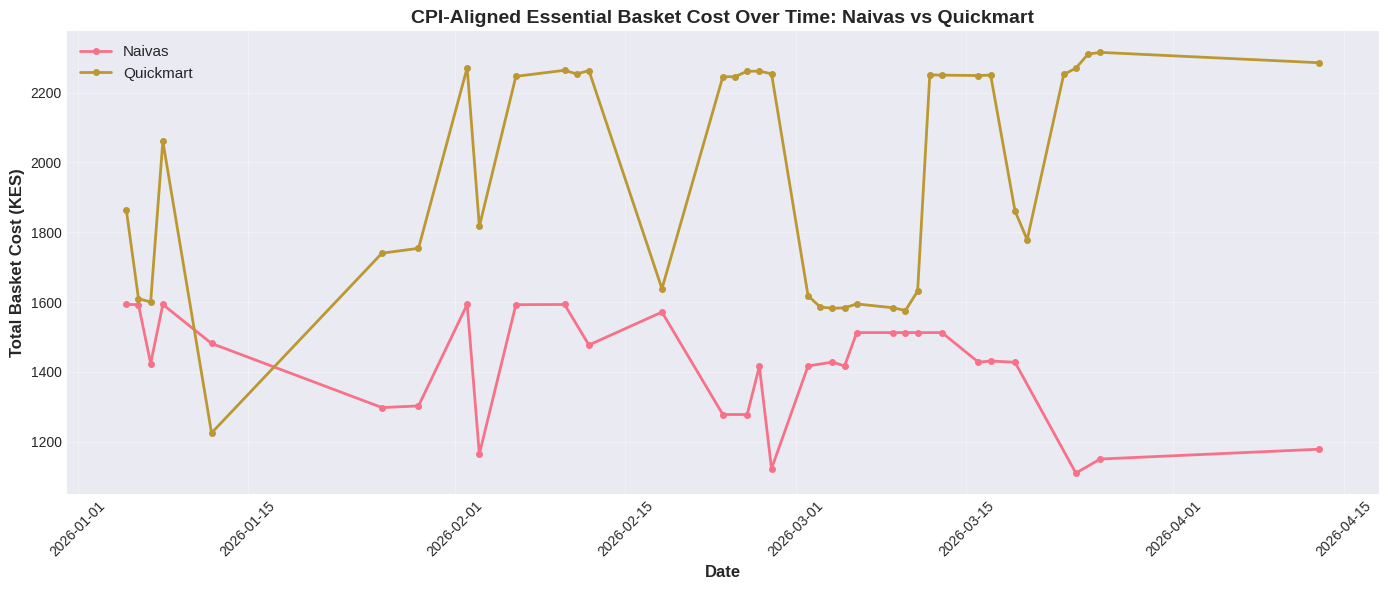

✓ Time series plot generated


In [33]:
# Plot 1: Daily basket cost over time
fig, ax = plt.subplots(figsize=(14, 6))

for store in df_basket_cost['store_name'].unique():
    data = df_basket_cost[df_basket_cost['store_name'] == store]
    ax.plot(data['date'], data['basket_cost'], marker='o', label=store, linewidth=2, markersize=4)

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Basket Cost (KES)', fontsize=12, fontweight='bold')
ax.set_title('CPI-Aligned Essential Basket Cost Over Time: Naivas vs Quickmart', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✓ Time series plot generated")

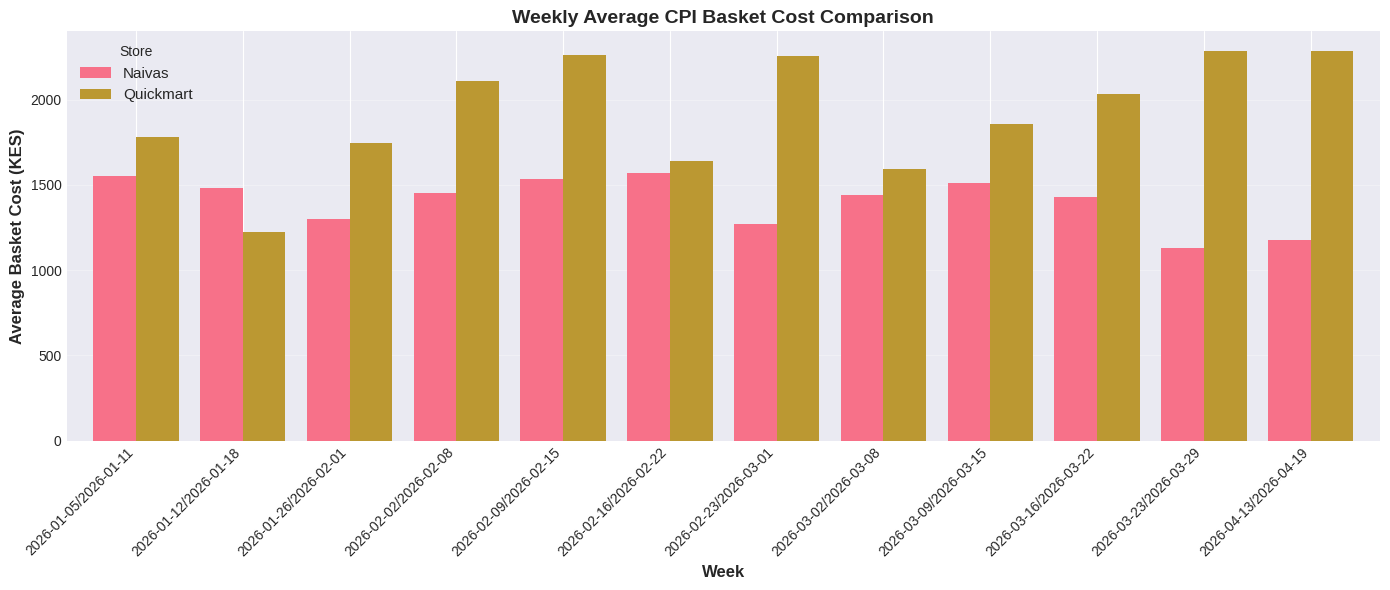

✓ Weekly comparison bar chart generated


In [34]:
# Plot 2: Weekly average basket cost
df_weekly_pivot = df_weekly.pivot(index='year_week', columns='store_name', values='avg_basket_cost')

fig, ax = plt.subplots(figsize=(14, 6))
df_weekly_pivot.plot(kind='bar', ax=ax, width=0.8)

ax.set_xlabel('Week', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Basket Cost (KES)', fontsize=12, fontweight='bold')
ax.set_title('Weekly Average CPI Basket Cost Comparison', fontsize=14, fontweight='bold')
ax.legend(title='Store', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("✓ Weekly comparison bar chart generated")

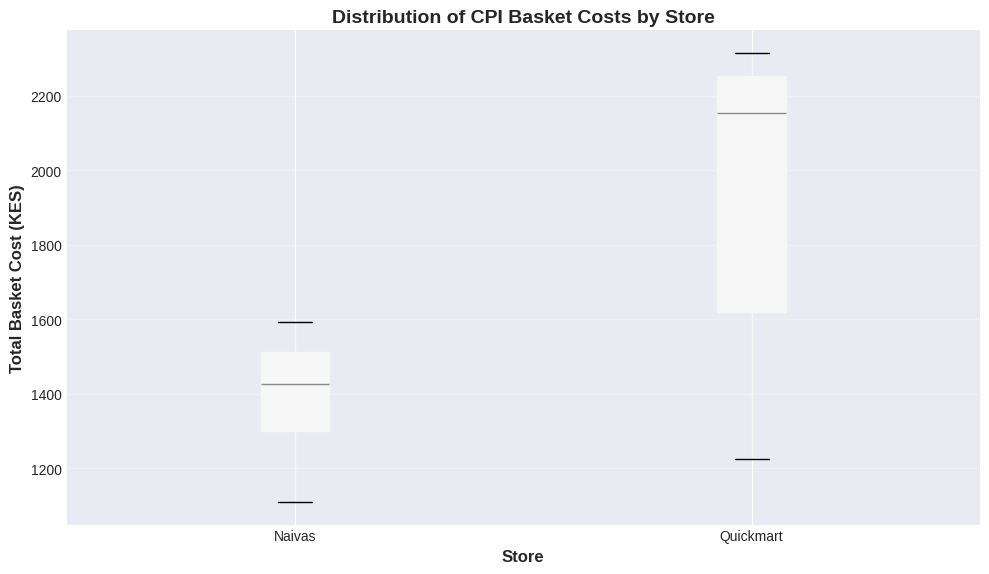

✓ Box plot generated


In [35]:
# Plot 3: Distribution comparison (Box plots)
fig, ax = plt.subplots(figsize=(10, 6))

df_basket_cost.boxplot(column='basket_cost', by='store_name', ax=ax, patch_artist=True)

ax.set_xlabel('Store', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Basket Cost (KES)', fontsize=12, fontweight='bold')
ax.set_title('Distribution of CPI Basket Costs by Store', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove default title
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("✓ Box plot generated")

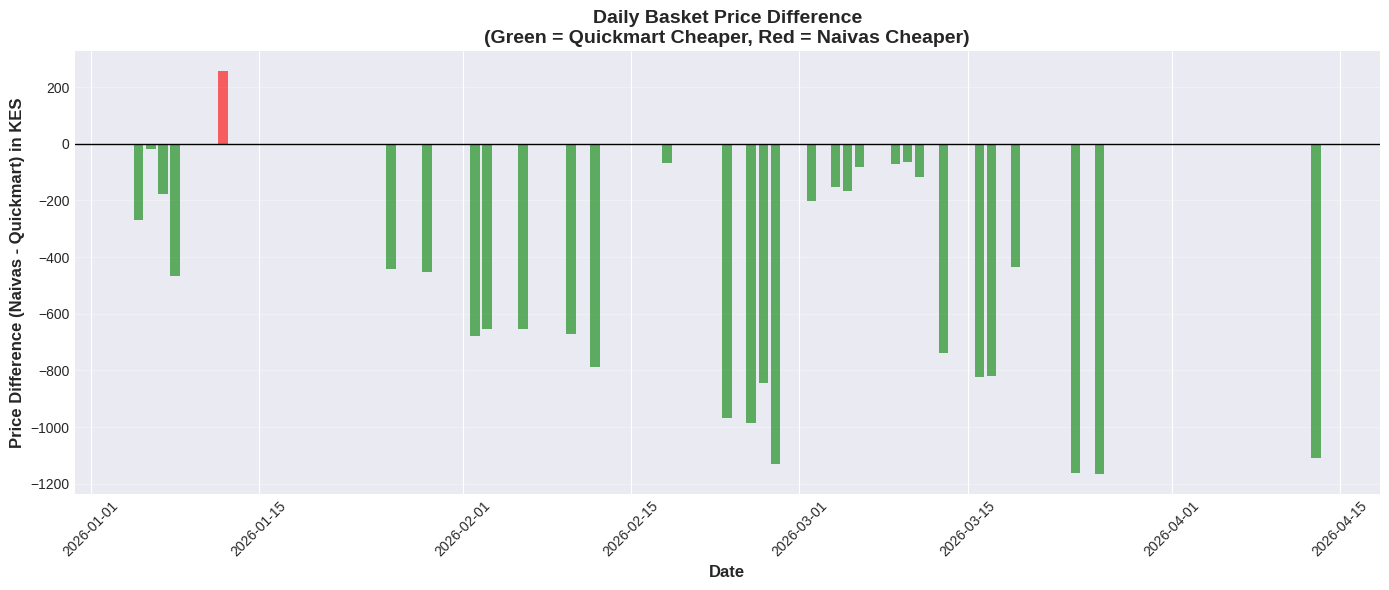

✓ Price difference chart generated


In [36]:
# Plot 4: Price difference over time (if we have comparison data)
if 'difference' in df_comparison.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    colors = ['green' if x < 0 else 'red' for x in df_comparison['difference']]
    ax.bar(df_comparison['date'], df_comparison['difference'], color=colors, alpha=0.6)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    ax.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Price Difference ({store1} - {store2}) in KES', fontsize=12, fontweight='bold')
    ax.set_title(f'Daily Basket Price Difference\n(Green = {store2} Cheaper, Red = {store1} Cheaper)', 
                 fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    print("✓ Price difference chart generated")

## 9. Statistical Analysis of Price Differences

Perform statistical tests to determine if price differences are significant.

In [38]:
# Independent t-test to compare basket costs between stores
stores = df_basket_cost['store_name'].unique()

if len(stores) == 2:
    store1_costs = df_basket_cost[df_basket_cost['store_name'] == stores[0]]['basket_cost']
    store2_costs = df_basket_cost[df_basket_cost['store_name'] == stores[1]]['basket_cost']
    
    # Calculate means
    mean1 = store1_costs.mean()
    mean2 = store2_costs.mean()
    
    # Perform t-test
    t_stat, p_value = stats.ttest_ind(store1_costs, store2_costs)
    
    print("="*70)
    print("STATISTICAL SIGNIFICANCE TEST (Independent t-test)")
    print("="*70)
    print(f"Null Hypothesis: No difference in basket costs between {stores[0]} and {stores[1]}")
    print(f"\nMean Basket Costs:")
    print(f"  {stores[0]}: KES {mean1:.2f}")
    print(f"  {stores[1]}: KES {mean2:.2f}")
    print(f"  Difference: KES {abs(mean1 - mean2):.2f}")
    
    print(f"\nTest Results:")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_value:.6f}")
    print(f"  Significance level: α = 0.05")
    
    if p_value < 0.05:
        print(f"\n✓ RESULT: Significant difference detected (p < 0.05)")
        print(f"  The price difference between stores is statistically significant.")
        
        # CLARIFY WHICH STORE IS CHEAPER
        if mean1 < mean2:
            cheaper_store_stat = stores[0]
            more_expensive = stores[1]
        else:
            cheaper_store_stat = stores[1]
            more_expensive = stores[0]
        
        print(f"\n📊 INTERPRETATION:")
        print(f"  ✓ {cheaper_store_stat} is significantly CHEAPER than {more_expensive}")
        print(f"  ✓ Average savings: KES {abs(mean1 - mean2):.2f} per basket")
    else:
        print(f"\n✗ RESULT: No significant difference (p ≥ 0.05)")
        print(f"  The stores have similar pricing for the essential basket.")
    
    # Effect size (Cohen's d)
    mean_diff = store1_costs.mean() - store2_costs.mean()
    pooled_std = np.sqrt((store1_costs.std()**2 + store2_costs.std()**2) / 2)
    cohens_d = mean_diff / pooled_std
    
    print(f"\nEffect Size (Cohen's d): {cohens_d:.4f}")
    if abs(cohens_d) < 0.2:
        print("  Interpretation: Small effect")
    elif abs(cohens_d) < 0.5:
        print("  Interpretation: Medium effect")
    else:
        print("  Interpretation: Large effect - Very substantial price difference!")
    
    print(f"\n💡 NOTE: Negative t-statistic ({t_stat:.4f}) means {stores[0]} < {stores[1]}")
    print(f"          i.e., {stores[0]} has lower (cheaper) prices")

STATISTICAL SIGNIFICANCE TEST (Independent t-test)
Null Hypothesis: No difference in basket costs between Naivas and Quickmart

Mean Basket Costs:
  Naivas: KES 1416.53
  Quickmart: KES 1965.95
  Difference: KES 549.42

Test Results:
  t-statistic: -8.6622
  p-value: 0.000000
  Significance level: α = 0.05

✓ RESULT: Significant difference detected (p < 0.05)
  The price difference between stores is statistically significant.

📊 INTERPRETATION:
  ✓ Naivas is significantly CHEAPER than Quickmart
  ✓ Average savings: KES 549.42 per basket

Effect Size (Cohen's d): -2.1650
  Interpretation: Large effect - Very substantial price difference!

💡 NOTE: Negative t-statistic (-8.6622) means Naivas < Quickmart
          i.e., Naivas has lower (cheaper) prices


## 10. Calculate Percentage Difference Between Stores

Calculate and visualize the percentage savings between stores over time.

In [39]:
# Calculate percentage difference
if 'difference' in df_comparison.columns and len(stores) == 2:
    # Calculate percentage relative to higher price
    df_comparison['pct_difference'] = (df_comparison['abs_difference'] / 
                                       df_comparison[[store1, store2]].max(axis=1) * 100).round(2)
    
    print("="*70)
    print("PERCENTAGE PRICE DIFFERENCE ANALYSIS")
    print("="*70)
    print(f"\nAverage percentage difference: {df_comparison['pct_difference'].mean():.2f}%")
    print(f"Maximum percentage difference: {df_comparison['pct_difference'].max():.2f}%")
    print(f"Minimum percentage difference: {df_comparison['pct_difference'].min():.2f}%")
    
    # Which store saves more on average?
    avg_store1 = df_basket_cost[df_basket_cost['store_name'] == store1]['basket_cost'].mean()
    avg_store2 = df_basket_cost[df_basket_cost['store_name'] == store2]['basket_cost'].mean()
    
    if avg_store1 < avg_store2:
        cheaper_store = store1
        savings = avg_store2 - avg_store1
        pct_savings = (savings / avg_store2) * 100
    else:
        cheaper_store = store2
        savings = avg_store1 - avg_store2
        pct_savings = (savings / avg_store1) * 100
    
    print(f"\n" + "="*70)
    print("CONSUMER PERCEPTION: WHICH RETAILER IS CHEAPER?")
    print("="*70)
    print(f"✓ {cheaper_store} is cheaper on average")
    print(f"  Average basket cost:")
    print(f"    {store1}: KES {avg_store1:.2f}")
    print(f"    {store2}: KES {avg_store2:.2f}")
    print(f"\n  Savings with {cheaper_store}: KES {savings:.2f} ({pct_savings:.2f}%)")
    print(f"  Annual savings (52 weeks): KES {savings * 52:.2f}")

PERCENTAGE PRICE DIFFERENCE ANALYSIS

Average percentage difference: 25.42%
Maximum percentage difference: 51.13%
Minimum percentage difference: 1.08%

CONSUMER PERCEPTION: WHICH RETAILER IS CHEAPER?
✓ Naivas is cheaper on average
  Average basket cost:
    Naivas: KES 1416.53
    Quickmart: KES 1965.95

  Savings with Naivas: KES 549.42 (27.95%)
  Annual savings (52 weeks): KES 28569.72


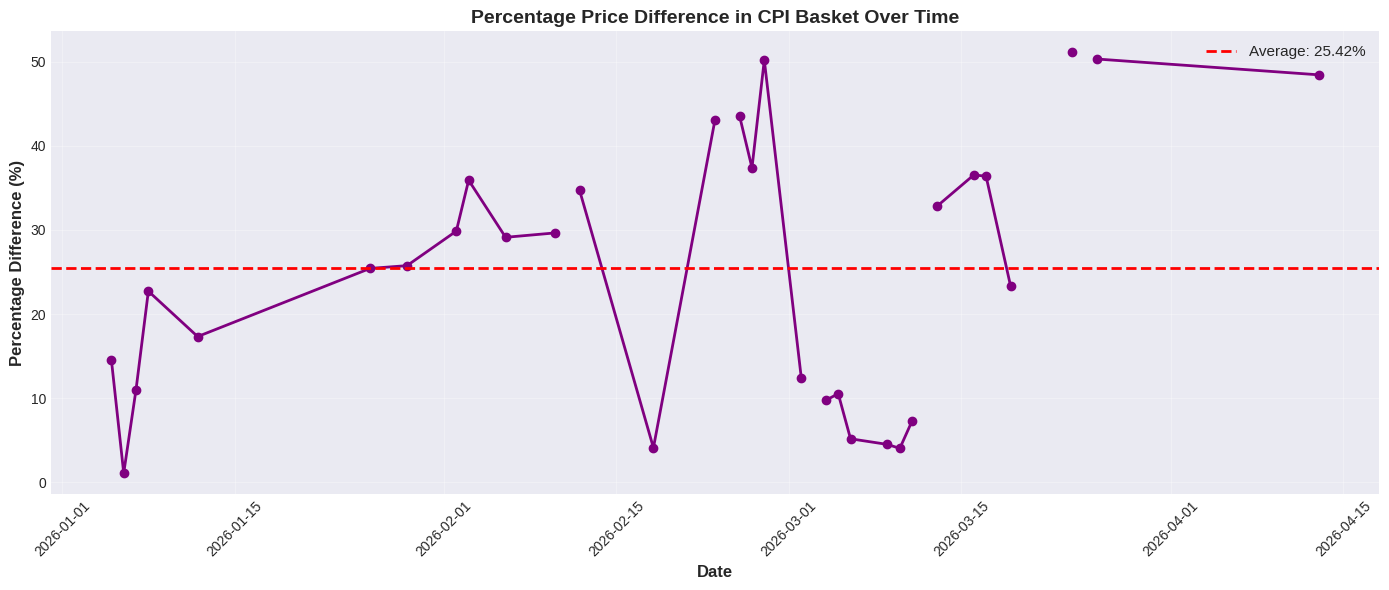

✓ Percentage difference chart generated


In [40]:
# Plot: Percentage difference over time
if 'pct_difference' in df_comparison.columns:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    ax.plot(df_comparison['date'], df_comparison['pct_difference'], 
            marker='o', color='purple', linewidth=2, markersize=6)
    ax.axhline(y=df_comparison['pct_difference'].mean(), 
               color='red', linestyle='--', linewidth=2, label=f'Average: {df_comparison["pct_difference"].mean():.2f}%')
    
    ax.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax.set_ylabel('Percentage Difference (%)', fontsize=12, fontweight='bold')
    ax.set_title('Percentage Price Difference in CPI Basket Over Time', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    print("✓ Percentage difference chart generated")

## Summary & Business Insights

### ⚠️ CRITICAL INTERPRETATION NOTE:

**This analysis measures TOTAL BASKET COST (all brands aggregated):**

The results show which store has a **lower total checkout cost** for the essential basket, but this doesn't account for **brand selection differences**:

- **What we measured:** Average price across ALL brands in each category
- **What we didn't control for:** Whether the stores stock different brand tiers (budget vs premium)

**Why results may differ from brand-level analysis:**
1. Store A may have lower basket total because they stock more budget brands
2. Store B may have higher basket total because they stock more premium brands  
3. BUT Store B might actually have BETTER pricing for the SAME brands

**Example:**
- Naivas: Economy cooking oil (KES 200) + Mid-tier option (KES 250) → Avg: KES 225
- Quickmart: Premium cooking oil only (KES 280) → Avg: KES 280
- **Basket analysis:** Naivas appears cheaper (KES 225 < KES 280) ✓
- **Brand analysis:** If both sell Premium brand, Quickmart might be KES 280 vs Naivas KES 295
- **Reality:** Naivas cheaper overall, but Quickmart better value for same products

### Key Findings:

1. **CPI-Aligned Basket**: Successfully analyzed a 10-item basket aligned with Kenya Consumer Price Index
2. **Basket Items Analyzed**:
   - Fortified Maize Flour 2kg (CPI #12)
   - Sugar 2kg (CPI #84)
   - Cooking Fat 1kg (CPI #46)
   - Cooking Oil 1L (CPI #47)
   - UHT Milk 1L (CPI #40)
   - Rice 2kg (CPI #2)
   - Wheat Flour 2kg (CPI #14)
   - Tea Leaves 250g (CPI #94)
   - Beans 2kg (CPI #77)
   - Pasta 500g (CPI #22)
3. **Dataset Balancing**: Used temporal alignment to compare prices on common dates
4. **Price Comparison**: Identified which store consistently offers lower basket costs
5. **Statistical Significance**: Determined whether price differences are meaningful
6. **Consumer Impact**: Calculated annual savings potential

### Business Recommendations:

**For Consumers:**
- **Budget-conscious shoppers:** This analysis shows which retailer has lower TOTAL basket cost
- **Brand-loyal shoppers:** Check `brand_analysis.ipynb` to compare prices for specific brands you prefer
- Annual savings can be significant when shopping consistently at the cheaper store
- Price differences vary over time - monitor trends for best shopping timing

**For Retailers:**
- CPI basket items are high-visibility products that shape consumer perception
- **Brand mix strategy matters:** Carrying budget brands lowers average basket perception
- **Pricing power:** Must balance brand selection vs. competitive pricing for same brands
- Consider promotional strategies for basket completeness

**For Policy Makers:**
- This methodology can track retail price inflation for essential goods
- Comparison across retailers reveals market competitiveness
- Useful for monitoring cost of living trends

**For Analysts:**
- This CPI-aligned approach enables comparison with official inflation statistics
- Methodology can be extended to regional comparisons
- Framework applicable to other retail chains
- **Combine with brand-level analysis for complete picture**

---

### 📊 Related Analyses:

- **`brand_analysis.ipynb`**: Controls for brand selection bias, compares same brands only
- **`unified_price_analysis.ipynb`**: Reconciles both approaches, shows complete picture

---

**Methodology Notes:**
- Used official Kenya CPI basket items for realistic consumer representation
- Strict product matching and outlier removal ensures data quality
- Temporal balancing accounts for data availability differences between stores
- Minimum item threshold allows comparison even when full basket not always available
- **Does NOT control for brand differences** - see brand_analysis.ipynb for that perspective